<a href="https://colab.research.google.com/github/PHYscodes/Ising-Model-DDIM/blob/main/2D_ising_model_Score_Matching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2D Ising Model Score-Based Generative Modeling

This notebook creates 2D Ising model spin configurations at a fixed temperature by training a Diffusion Model (via Score Matching).



Binary spins $\sigma_i \in \{-1, +1\}$ on a square lattice make up the 2D Ising model. At the crucial temperature $T_c \approx 2.269$, it experiences a ferromagnetic phase change.

* The magnetization's probability distribution, $m = \frac{1}{N}\sum \sigma_i$, is
* This intricate, split probability landscape must be learned by our generative model!


With a cosine noise schedule, we employ a **variance-preserving SDE**: $x_t = \alpha(t)x_0 + \beta(t)\epsilon$.
We employ the **$v$-parameterization** to increase numerical stability close to $t \to 0$, where the continuous mathematical variables need to snap into discrete physical spins:
$$v = \alpha(t)\epsilon - \beta(t)x_0$$



In [1]:
from __future__ import annotations

import copy
import math
import multiprocessing as mp
import os
import random
from typing import List, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt


In [2]:
#σ ∈ {-1,+1}: spin configuration
#H(σ) = -J Σ σᵢσⱼ: Hamiltonian
#α(t) = cos(πt/2): cosine schedule
#γ(t) = sin(πt/2): sine schedule
#ε ~ N(0,I): Gaussian noise
#xₜ = α·x₀ + γ·ε  : noisy sample
#v_target = α·ε - γ·x₀: velocity target
#v_predvθ(xₜ, t, T): network output
#x̂₀ = α·xₜ - γ·vθ: clean estimate
#ε̂  = γ·xₜ + α·vθ: noise estimate
#σₜ: DDIM noise scale
#θ_EMA : EMA parameters
#E[||v_pred - v_target||²] : training loss
#
#for ANY lattice side length L ≥ 2.

#HYPERPARAMETERS
L= 6 # Lattice side length  — any L ≥ 2 works
N= L * L # Total spins  N = L²
J= 1.0 # Coupling constant
T_c= 2.0 * J / math.log(1.0 + math.sqrt(2.0))

T_train       = 3.0 # Training temperature  T
T_min         = 0.5 # Min T for normalisation
T_max         = 4.5 # Max T for normalisation

eq_sweeps     = 2000
mc_sweeps     = 5000 # Production sweeps
sample_intv   = 10 # Sweeps between saved σ

SEED          = 44
batch_size    = 256
n_epochs      = 200
lr            = 1e-4
ema_decay     = 0.999 # β  in  θ_EMA ← β·θ_EMA + (1-β)·θ
grad_clip     = 1.0
warmup_epochs = 20

n_samples_gen = 64 # Configs to generate after training
ddim_steps    = 500 # Reverse steps  tT > … > t0
eta           = 0.8 # η: 0 = deterministic DDIM, 1 = DDPM
discretize    = "end_sign"  # "end_sign" | "tanh_anneal" | "stochastic_end"
tanh_k_final  = 10.0 # Final λ_k for tanh annealing

base_channels = 64 # U-Net base channel width

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)



In [3]:
# ISING MC DATA GENERATION
# Sample σ ~ p(σ|T) = e^{-H(σ)/T} / Z(T)

def metropolis_sweep(sigma: np.ndarray,
                     beta: float,
                     rng: np.random.Generator) -> None:
    """
    One full checkerboard Metropolis sweep.

    Acceptance criterion derived from H(σ) = -J Σ_{<i,j>} σᵢσⱼ  (Eq. 2):
        ΔH = 2J σᵢ Σ_{j∈N(i)} σⱼ
    Accept if ΔH ≤ 0, else with probability e^{-β·ΔH}.
    Periodic boundary conditions (torus geometry).


    sigma: (L, L) int8 array  σᵢ ∈ {-1, +1}
    beta: inverse temperature  β = 1/T
    rng: numpy random generator
    """
    lattice_L = sigma.shape[0]
    for parity in (0, 1):
        ii, jj = np.meshgrid(np.arange(lattice_L),
                             np.arange(lattice_L), indexing="ij")
        mask   = (ii + jj) % 2 == parity
        i_idx  = ii[mask]
        j_idx  = jj[mask]

        sigma_i = sigma[i_idx, j_idx]

        # Nearest-neighbour sum  Σ_{j∈N(i)} σⱼ
        nn_sum = (
            sigma[(i_idx + 1) % lattice_L, j_idx]
            + sigma[(i_idx - 1) % lattice_L, j_idx]
            + sigma[i_idx, (j_idx + 1) % lattice_L]
            + sigma[i_idx, (j_idx - 1) % lattice_L]
        )

        delta_H = 2.0 * J * sigma_i * nn_sum          # ΔH
        rand_u  = rng.random(size=sigma_i.shape)
        accept  = (delta_H <= 0) | (rand_u < np.exp(-beta * delta_H))
        sigma[i_idx[accept], j_idx[accept]] *= -1


def _mc_worker(args: tuple) -> np.ndarray:
    """
    Parallel MC chain worker.
    Returns array of flattened spin configs σ ∈ {-1,+1}^N.
    """
    lattice_L, T, eq_sw, mc_sw, s_intv, seed = args
    rng  = np.random.default_rng(seed)
    beta = 1.0 / T

    sigma = rng.choice([-1, 1],
                       size=(lattice_L, lattice_L)).astype(np.int8)


    for _ in range(eq_sw):
        metropolis_sweep(sigma, beta, rng)

    # save one config every s_intv sweeps
    configs = []
    for _ in range(mc_sw):
        for _ in range(s_intv):
            metropolis_sweep(sigma, beta, rng)
        configs.append(sigma.copy().flatten().astype(np.float32))

    return np.array(configs, dtype=np.float32)


In [4]:
def generate_ising_configurations(
    lattice_L:int = L,
    T:float = T_train,
    mc_sw:int   = mc_sweeps,
    eq_sw:int   = eq_sweeps,
    s_intv:int   = sample_intv,
    num_workers:int | None = None,
    force_regen:bool  = False,
) -> np.ndarray:
    """
    Generate (or load cached) Ising spin configurations at temperature T.

    Returns
    -------
    sigma_dataset : (N_configs, L*L) float32  — each row is σ ∈ {-1,+1}^N
    """
    fname = f"ising_L{lattice_L}_T{T:.3f}.npy"

    if os.path.exists(fname) and not force_regen:
        sigma_dataset = np.load(fname).astype(np.float32)
        print(f"[Data] Loaded  {fname}  shape={sigma_dataset.shape}")
        return sigma_dataset

    if num_workers is None:
        num_workers = max(1, os.cpu_count() or 1)

    steps_per_worker = max(1, mc_sw // num_workers)
    seeds = [int(np.random.randint(0, 2**31)) for _ in range(num_workers)]
    worker_args = [
        (lattice_L, T, eq_sw, steps_per_worker, s_intv, seeds[k])
        for k in range(num_workers)
    ]

    print(f"[Data] Generating: L={lattice_L}, T={T:.3f}, "
          f"workers={num_workers}, steps/worker={steps_per_worker}")

    with mp.Pool(processes=num_workers) as pool:
        results = pool.map(_mc_worker, worker_args)

    sigma_dataset = np.vstack(results)
    np.save(fname, sigma_dataset)
    print(f"[Data] Saved {len(sigma_dataset)} configs → {fname}  "
          f"shape={sigma_dataset.shape}")
    return sigma_dataset



# PHYSICS OBSERVABLES
# m(σ) = (1/N) Σᵢ σᵢ
# H(σ) = -J Σ_{<i,j>} σᵢσⱼ  per spin
# C(r)  = <σ(0) σ(r)>

def hamiltonian(sigma: np.ndarray) -> float:
    """H(σ)/N = -J Σ_{<i,j>} σᵢσⱼ / N   No double-counting."""
    H_val  = -J * np.sum(sigma * np.roll(sigma, -1, axis=0))
    H_val -= J  * np.sum(sigma * np.roll(sigma, -1, axis=1))
    return float(H_val) / sigma.size


def magnetization(sigma: np.ndarray) -> float:
    """m(σ) = (1/N) Σᵢ σᵢ  (Eq. 5)."""
    return float(np.mean(sigma))


def spin_spin_correlation(sigma: np.ndarray) -> np.ndarray:
    """C(r) = <σ(0) σ(r)> averaged over all origin sites."""
    lattice_L = sigma.shape[0]
    return np.array([
        float(np.mean(sigma * np.roll(sigma, -r, axis=0)))
        for r in range(lattice_L)
    ])


In [7]:
def plot_spin_configurations(
    sigma_array:np.ndarray,
    lattice_L:int,
    title:str = "Spin Configurations σ",
    num_show:int = 16,
) -> None:
    """Display a grid of spin configs σ ∈ {-1,+1}^{L×L}."""
    n    = min(num_show, len(sigma_array))
    cols = max(1, int(math.sqrt(n)))
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = np.array(axes).flatten()
    for i in range(n):
        axes[i].imshow(
            sigma_array[i].reshape(lattice_L, lattice_L),
            cmap="binary", vmin=-1, vmax=1)
        axes[i].axis("off")
    for i in range(n, len(axes)):
        axes[i].axis("off")
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_magnetization_distribution(
    m_mc:  np.ndarray,
    m_gen: np.ndarray,
    T:     float,
) -> None:
    """Histogram of m(σ) = (1/N) Σᵢ σᵢ """
    plt.figure(figsize=(8, 4))
    bins = np.linspace(-1, 1, N + 1)  # exact discrete bins
    plt.hist(m_mc,  bins=bins, density=True, alpha=0.6,
             color="gray",    label=r"MC Data  $p(\sigma|T)$")
    plt.hist(m_gen, bins=bins, density=True, alpha=0.6,
             color="#4C78A8", label=r"Generated  $v_\theta$")
    plt.title(f"Magnetisation Distribution  $m(\\sigma)$   T = {T:.3f}")
    plt.xlabel(r"$m(\sigma) = \frac{1}{N}\sum_i \sigma_i$")
    plt.ylabel("Density")
    plt.xlim(-1.1, 1.1)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Device  : cuda
Lattice : L=6,  N=L²=36 spins
T_train : 3.000   (T_c ≈ 2.269)

[1/4] Generating / loading Ising spin configurations...
[Data] Loaded  ising_L6_T3.000.npy  shape=(5000, 36)
  sigma_dataset : (5000, 36)
  T_scaled      : 0.6250
  Batches/epoch : 19


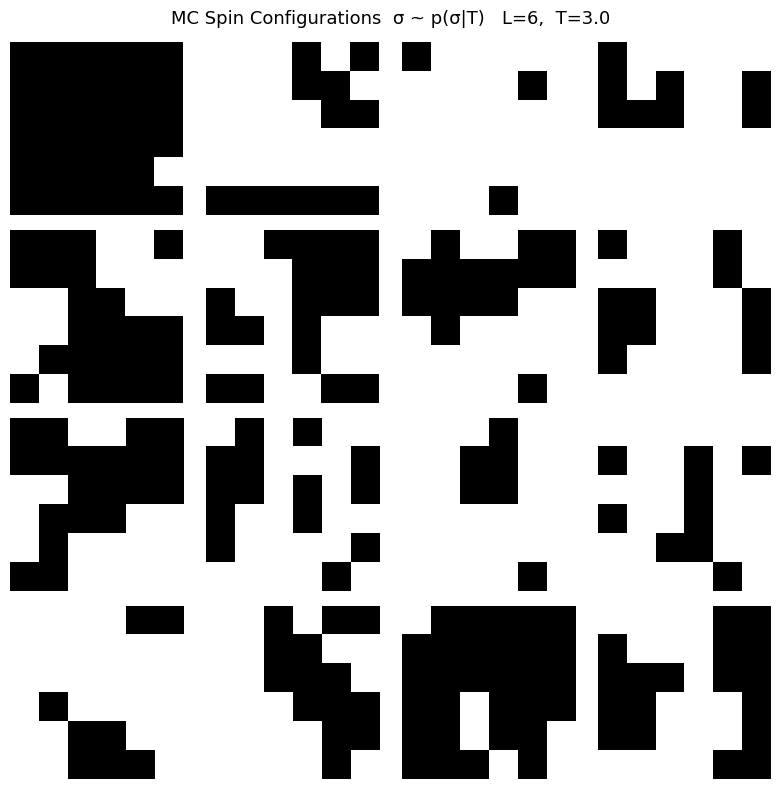

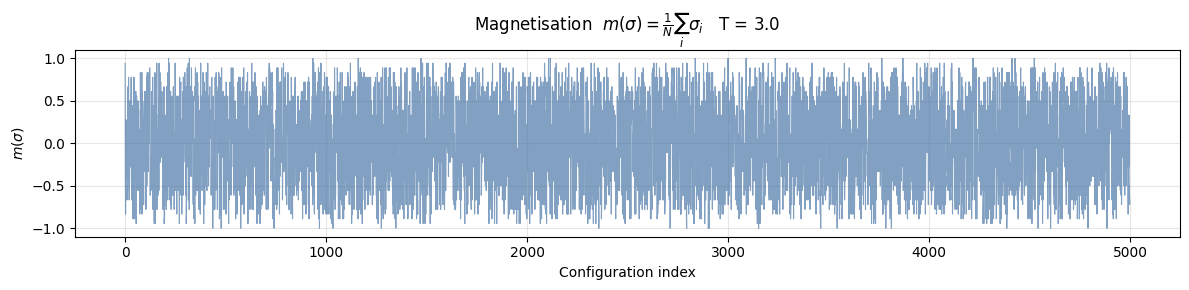

In [8]:
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device  : {device}")
print(f"Lattice : L={L},  N=L²={N} spins")
print(f"T_train : {T_train:.3f}   (T_c ≈ {T_c:.3f})")

# ── 1. Generate / load σ ~ p(σ|T)  (Eq. 3) ──────────────────────────
print("\n[1/4] Generating / loading Ising spin configurations...")
sigma_dataset = generate_ising_configurations(
    lattice_L=L, T=T_train,
    mc_sw=mc_sweeps, eq_sw=eq_sweeps, s_intv=sample_intv,
)

T_scaled_train = float(
    np.clip((T_train - T_min) / (T_max - T_min), 0.0, 1.0)
)
T_labels = np.full(
    (len(sigma_dataset), 1), T_scaled_train, dtype=np.float32
)
print(f"  sigma_dataset : {sigma_dataset.shape}")
print(f"  T_scaled      : {T_scaled_train:.4f}")

bs = min(batch_size, len(sigma_dataset))
if bs < 2:
    raise RuntimeError("Too few samples — increase mc_sweeps.")

dataloader = DataLoader(
    TensorDataset(torch.tensor(sigma_dataset),
                  torch.tensor(T_labels)),
    batch_size=bs, shuffle=True, drop_last=True, num_workers=0,
)
print(f"  Batches/epoch : {len(dataloader)}")

# ── 2. Visualise MC data ──────────────────────────────────────────────
plot_spin_configurations(
    sigma_dataset, L,
    title=f"MC Spin Configurations  σ ~ p(σ|T)   L={L},  T={T_train}",
    num_show=16,
)

# m(σ) = (1/N) Σᵢ σᵢ  time series  (Eq. 5)
m_mc = sigma_dataset.mean(axis=1)
plt.figure(figsize=(12, 3))
plt.plot(m_mc, color="#4C78A8", alpha=0.7, lw=0.8)
plt.title(
    r"Magnetisation  $m(\sigma) = \frac{1}{N}\sum_i \sigma_i$"
    f"   T = {T_train}"
)
plt.xlabel("Configuration index")
plt.ylabel(r"$m(\sigma)$")
plt.ylim(-1.1, 1.1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# NEURAL NETWORK BUILDING BLOCKS
# Implements vθ(xₜ, t, T)

def safe_group_norm(num_channels: int, max_groups: int = 32) -> nn.GroupNorm:
    """
    GroupNorm with automatic group count selection.

    PyTorch requires num_channels % num_groups == 0   ^1^ .
    This helper finds the largest valid divisor ≤ max_groups,
    falling back to GroupNorm(1, C) (≡ LayerNorm) if needed.
    Works for any channel count including 1.
    """
    if num_channels == 1:
        # GroupNorm(1, 1) is valid and equivalent to LayerNorm
        return nn.GroupNorm(1, num_channels)
    g = min(max_groups, num_channels)
    while g > 1 and num_channels % g != 0:
        g -= 1
    return nn.GroupNorm(g, num_channels)


class SinusoidalTimeEmbedding(nn.Module):
    """
    Sinusoidal time embedding
        λ_{2k}(t)   = sin(ω_k · t)
        λ_{2k+1}(t) = cos(ω_k · t)
        ω_k         = 10000^{-2k/d}
    """
    def __init__(self, embed_dim: int):
        super().__init__()
        self.embed_dim = embed_dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        half    = self.embed_dim // 2
        # ω_k = 10000^{-2k/d}
        omega_k = torch.exp(
            torch.arange(half, device=t.device, dtype=torch.float32)
            * (-math.log(10_000.0) / max(half - 1, 1))
        )
        args = t * omega_k[None, :]                     # (B, half)
        # λ_{2k} = sin,  λ_{2k+1} = cos
        return torch.cat([torch.sin(args),
                          torch.cos(args)], dim=-1)     # (B, embed_dim)


class ResBlock(nn.Module):
    """
    Residual double-conv block for vθ.

    Design choices:
    - Circular padding  → periodic boundary conditions on the lattice
    - safe_group_norm   → valid for any channel count / grid size   ^1^
    - Embedding injection via linear projection of (t, T) embedding
    - Residual skip for stable gradient flow
    """
    def __init__(self, in_ch: int, out_ch: int, embed_dim: int):
        super().__init__()
        self.conv1    = nn.Conv2d(in_ch,  out_ch, 3,
                                  padding=1, padding_mode="circular")
        self.norm1    = safe_group_norm(out_ch)
        self.conv2    = nn.Conv2d(out_ch, out_ch, 3,
                                  padding=1, padding_mode="circular")
        self.norm2    = safe_group_norm(out_ch)
        self.act      = nn.GELU()
        self.emb_proj = nn.Linear(embed_dim, out_ch)
        self.skip     = (nn.Conv2d(in_ch, out_ch, 1)
                         if in_ch != out_ch else nn.Identity())

    def forward(self, x: torch.Tensor, emb: torch.Tensor) -> torch.Tensor:
        # emb: (B, embed_dim) → (B, out_ch, 1, 1)
        e = self.emb_proj(emb).unsqueeze(-1).unsqueeze(-1)
        h = self.act(self.norm1(self.conv1(x))) + e
        h = self.act(self.norm2(self.conv2(h)))
        return h + self.skip(x)


class VelocityNetUNet(nn.Module):
    """
    Conditional U-Net parameterising the velocity field vθ(xₜ, t, T).

    Inputs
    ------
    x_t_flat : (B, N)   noisy spin config xₜ
    t        : (B, 1)   diffusion time t ∈ (0,1)
    T_scaled : (B, 1)   temperature normalised to [0,1]

    Output
    ------
    v_pred   : (B, N)   predicted velocity vθ(xₜ, t, T)

    Automatically adapts to any lattice size L:
      - depth computed from L (capped at 3 for stability)
      - F.interpolate handles odd spatial sizes in the decoder
      - safe_group_norm handles any channel count   ^1^
    """
    def __init__(self, lattice_L: int = L, base_ch: int = base_channels):
        super().__init__()
        self.lattice_L = lattice_L
        embed_dim      = base_ch * 4

        # Time embedding
        self.time_embed = nn.Sequential(
            SinusoidalTimeEmbedding(embed_dim),
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, embed_dim),
        )

        # Temperature embedding
        self.temp_embed = nn.Sequential(
            nn.Linear(1, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, embed_dim),
        )

        #  Dynamic depth: halve until spatial size < 4
        depth, sz = 0, lattice_L
        while sz >= 4:
            depth += 1
            sz   //= 2
        self.depth = max(1, min(depth, 3))

        # Channel schedule: [1, C, 2C, 4C, ...]
        ch = [1] + [base_ch * (2 ** i) for i in range(self.depth)]

        #  Encoder
        self.enc_blocks = nn.ModuleList([
            ResBlock(ch[i], ch[i + 1], embed_dim)
            for i in range(self.depth)
        ])
        self.downsample = nn.ModuleList([
            nn.MaxPool2d(2) for _ in range(self.depth)
        ])

        # Bottleneck
        btn_ch          = ch[-1] * 2
        self.bottleneck = ResBlock(ch[-1], btn_ch, embed_dim)

        # Decoder
        self.upsample   = nn.ModuleList()
        self.dec_blocks = nn.ModuleList()
        in_ch = btn_ch
        for i in range(self.depth - 1, -1, -1):
            skip_ch = ch[i + 1]
            out_ch  = ch[i + 1] if i > 0 else base_ch
            self.upsample.append(
                nn.ConvTranspose2d(in_ch, skip_ch, 2, stride=2)
            )
            self.dec_blocks.append(
                ResBlock(skip_ch * 2, out_ch, embed_dim)
            )
            in_ch = out_ch

        # Final 1×1 conv → scalar field over lattice
        self.output_conv = nn.Conv2d(base_ch, 1, kernel_size=1)

    def forward(
        self,
        x_t_flat: torch.Tensor,   # (B, N)  noisy config xₜ
        t:        torch.Tensor,   # (B, 1)  diffusion time
        T_scaled: torch.Tensor,   # (B, 1)  normalised temperature
    ) -> torch.Tensor:            # (B, N)  predicted velocity vθ

        B    = x_t_flat.shape[0]
        x_2d = x_t_flat.view(B, 1, self.lattice_L, self.lattice_L)

        # Combined embedding: time + temperature  (Eq. 25–27, Sec. 1.7)
        emb = self.time_embed(t) + self.temp_embed(T_scaled)  # (B, embed_dim)

        # Encoder
        skip_connections = []
        h = x_2d
        for enc, down in zip(self.enc_blocks, self.downsample):
            h = enc(h, emb)
            skip_connections.append(h)
            h = down(h)

        # Bottleneck
        h = self.bottleneck(h, emb)

        # Decoder — F.interpolate handles odd sizes from any L
        for up, dec, skip in zip(self.upsample, self.dec_blocks,
                                  reversed(skip_connections)):
            h = up(h)
            h = F.interpolate(h, size=skip.shape[2:], mode="nearest")
            h = torch.cat([h, skip], dim=1)
            h = dec(h, emb)

        return self.output_conv(h).view(B, -1)   # (B, N)

In [11]:
#EMA  —  θ_EMA ← β·θ_EMA + (1-β)·θ

class EMA:
    """
    Exponential Moving Average of model parameters.
    Stabilises sampling by providing smoother vθ estimates
    """
    def __init__(self, beta: float = 0.999):
        self.beta = beta

    @torch.no_grad()
    def update(self, theta_ema: nn.Module, theta: nn.Module) -> None:
        """θ_EMA ← β·θ_EMA + (1-β)·θ  """
        for p, p_ema in zip(theta.parameters(), theta_ema.parameters()):
            p_ema.data.mul_(self.beta).add_(p.data, alpha=1.0 - self.beta)



In [12]:
# COSINE NOISE SCHEDULE
# α(t) = cos(πt/2),  γ(t) = sin(πt/2)
# Variance-preserving: α(t)² + γ(t)² = 1
def cosine_schedule(t: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Cosine noise schedule
        α(t) = cos(π/2 · t)
        γ(t) = sin(π/2 · t)

    Forward process:  xₜ = α(t)·x₀ + γ(t)·ε
    Variance-preserving: α(t)² + γ(t)² = 1

    Returns
    -------
    alpha_t : α(t) = cos(πt/2)
    gamma_t : γ(t) = sin(πt/2)
    """
    alpha_t = torch.cos((math.pi / 2.0) * t)
    gamma_t = torch.sin((math.pi / 2.0) * t)
    return alpha_t, gamma_t


def discretize_spins(x: torch.Tensor) -> torch.Tensor:
    """
    Map continuous output → discrete spins σᵢ ∈ {-1,+1}  (Eq. 43):
        sᵢ = sign(xᵢ),  with the convention sign(0) := +1.
    """
    s = torch.sign(x)
    s[s == 0] = 1.0
    return s



In [16]:
# TRAINING
# L_score = E[||v_pred - v_target||²]
# v_target = α(t)·ε - γ(t)·x₀

def train_score_model(
    v_theta:nn.Module,
    dataloader:DataLoader,
    device:torch.device,
    n_epochs:int   = n_epochs,
    lr:float = lr,
    ema_decay:float = ema_decay,
    grad_clip:float = grad_clip,
    warmup:int   = warmup_epochs,
) -> Tuple[nn.Module, nn.Module, List[float]]:
    """
    Train vθ(xₜ, t, T) by minimising L_score

    Algorithm :
      1. Sample x₀ ~ p_data,  t ~ U(0,1)
      2. Sample ε ~ N(0,I)
      3. xₜ = α(t)·x₀ + γ(t)·ε
      4. v_target = α(t)·ε - γ(t)·x₀
      5. v_pred = vθ(xₜ, t, T)
      6. L_score = E[||v_pred - v_target||²]
      7. θ_EMA ← β·θ_EMA + (1-β)·θ
    """
    v_theta   = v_theta.to(device)
    theta_ema = copy.deepcopy(v_theta).to(device).eval()
    for p in theta_ema.parameters():
        p.requires_grad_(False)

    ema_updater = EMA(beta=ema_decay)
    optimiser   = optim.AdamW(v_theta.parameters(),
                              lr=lr, weight_decay=1e-4)

    def lr_lambda(epoch: int) -> float:
        if epoch < warmup:
            return (epoch + 1) / warmup
        progress = (epoch - warmup) / max(n_epochs - warmup, 1)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    scheduler = optim.lr_scheduler.LambdaLR(optimiser, lr_lambda)
    mse_loss  = nn.MSELoss()
    L_score_history: List[float] = []

    for epoch in range(n_epochs):
        v_theta.train()
        epoch_loss, n_batches = 0.0, 0

        for x0, T_scaled in dataloader:
            x0, T_scaled = x0.to(device), T_scaled.to(device)

            # Z₂ symmetry augmentation: σ → -σ leaves H(σ) invariant
            if torch.rand(1).item() < 0.5:
                x0 = -x0

            B = x0.size(0)

            # Step 1: t ~ U(0,1)  (clipped for numerical safety)
            t = torch.rand(B, 1, device=device) * 0.995 + 0.0025

            # Step 2: ε ~ N(0,I)
            epsilon = torch.randn_like(x0)

            # Step 3: xₜ = α(t)·x₀ + γ(t)·ε
            alpha_t, gamma_t = cosine_schedule(t)
            x_t = alpha_t * x0 + gamma_t * epsilon

            # Step 4: v_target = α(t)·ε - γ(t)·x₀
            v_target = alpha_t * epsilon - gamma_t * x0

            # Step 5: v_pred = vθ(xₜ, t, T)
            v_pred = v_theta(x_t, t, T_scaled)

            # Step 6: L_score = E[||v_pred - v_target||²]
            L_score = mse_loss(v_pred, v_target)

            optimiser.zero_grad(set_to_none=True)
            L_score.backward()
            torch.nn.utils.clip_grad_norm_(v_theta.parameters(), grad_clip)
            optimiser.step()

            # Step 7: θ_EMA ← β·θ_EMA + (1-β)·θ
            ema_updater.update(theta_ema, v_theta)

            epoch_loss += L_score.item()
            n_batches  += 1

        scheduler.step()
        avg_L_score = epoch_loss / max(n_batches, 1)
        L_score_history.append(avg_L_score)

        if epoch == 0 or (epoch + 1) % 20 == 0:
            current_lr = optimiser.param_groups[0]["lr"]
            print(f"  [Epoch {epoch+1:03d}/{n_epochs}]  "
                  f"L_score={avg_L_score:.6f}  lr={current_lr:.2e}")

    return v_theta, theta_ema, L_score_history


In [17]:
# DDIM SAMPLING
#
#  At each reverse step  tT > tT-1 > … > t0
#
#    v_pred= vθ(xₜ, t, T)
#    x̂₀= α(t)·xₜ  - γ(t)·v_pred
#    ε̂ = γ(t)·xₜ  + α(t)·v_pred
#    σₜ= η √[(1-α²_{t-1})/(1-α²ₜ)] √[1 - α²ₜ/α²_{t-1}]
#    c_det= √[γ(t-1)² - σₜ²]
#    xₜ₋₁= α(t-1)·x̂₀ + c_det·ε̂ + σₜ·z
#
#  Numerically stable: all sqrt arguments clamped ≥ 0


@torch.no_grad()
def ddim_sample(
    theta_ema:nn.Module,
    T_phys:float,
    n_configs:int,
    device:torch.device,
    n_steps:int   = ddim_steps,
    eta:float = eta,
    disc_method:str   = discretize,
    tanh_k:float = tanh_k_final,
    lattice_L:int   = L,
    T_min:float = T_min,
    T_max:float = T_max,
) -> np.ndarray:
    """
    Generate spin configurations via DDIM reverse diffusion
    T_phys: physical temperature T of the Ising model
    n_configs: number of σ configurations to generate
    eta: η — stochasticity (0 = deterministic, 1 = DDPM-like)
    disc_method: spin discretisation strategy
    """
    theta_ema.eval()
    N_spins = lattice_L * lattice_L

    # Normalise T ∈ [T_min, T_max] → [0, 1] for network conditioning
    T_scaled_val = float(
        np.clip((T_phys - T_min) / (T_max - T_min), 0.0, 1.0)
    )
    T_scaled = torch.full((n_configs, 1), T_scaled_val, device=device)

    # Step 1: xT ~ N(0,I)  (Eq. 37)
    x_t = torch.randn(n_configs, N_spins, device=device)

    # Discrete time grid  tT > tT-1 > … > t0
    t_high, t_low = 0.9975, 0.0025
    time_steps = torch.linspace(
        t_high, t_low, n_steps + 1, device=device
    ).view(-1, 1)

    for step_i in range(n_steps):
        t_cur  = time_steps[step_i    ].expand(n_configs, 1)
        t_prev = time_steps[step_i + 1].expand(n_configs, 1)

        alpha_t,      gamma_t      = cosine_schedule(t_cur)
        alpha_t_prev, gamma_t_prev = cosine_schedule(t_prev)

        # Step 3: v_pred = vθ(xₜ, t, T)
        v_pred = theta_ema(x_t, t_cur, T_scaled)

        # Step 4a: x̂₀ = α(t)·xₜ - γ(t)·v_pred
        x0_hat = alpha_t * x_t - gamma_t * v_pred
        x0_hat = x0_hat.clamp(-1.0, 1.0)          # clip for stability

        # Step 4b: ε̂ = γ(t)·xₜ + α(t)·v_pred
        epsilon_hat = gamma_t * x_t + alpha_t * v_pred

        #step5
        alpha_sq      = (alpha_t      ** 2).clamp(min=1e-8)
        alpha_sq_prev = (alpha_t_prev ** 2).clamp(min=1e-8)

        # σₜ = η · √[(1-α²_{t-1})/(1-α²ₜ)] · √[1 - α²ₜ/α²_{t-1}]
        ratio     = ((1.0 - alpha_sq_prev) /
                     (1.0 - alpha_sq).clamp(min=1e-8)).clamp(min=0.0)
        inner     = (1.0 - alpha_sq /
                     alpha_sq_prev.clamp(min=1e-8)).clamp(min=0.0)
        sigma_t   = eta * torch.sqrt(ratio) * torch.sqrt(inner)
        sigma_t   = sigma_t.clamp(min=0.0)

        # Deterministic direction coefficient  √(γ(t-1)² - σₜ²)
        c_det = torch.sqrt(
            (gamma_t_prev ** 2 - sigma_t ** 2).clamp(min=0.0)
        )

        # z ~ N(0,I)
        z = torch.randn_like(x_t) if eta > 0 else 0.0

        # Step 5: xₜ₋₁ = α(t-1)·x̂₀ + c_det·ε̂ + σₜ·z
        x_t = alpha_t_prev * x0_hat + c_det * epsilon_hat + sigma_t * z

        # Progressive tanh annealing  sᵢ = tanh(λ_k · xᵢ)
        if disc_method == "tanh_anneal":
            progress = (step_i + 1) / n_steps
            lambda_k = 1.0 + (tanh_k - 1.0) * progress
            x_t = torch.tanh(lambda_k * x_t)

    #Spin Discretisation
    if disc_method in ("end_sign", "tanh_anneal"):
        sigma_generated = discretize_spins(x_t)          # sᵢ = sign(xᵢ)
    elif disc_method == "stochastic_end":
        prob            = (torch.tanh(x_t) + 1.0) / 2.0
        sigma_generated = (torch.rand_like(prob) < prob).float() * 2.0 - 1.0
    else:
        sigma_generated = discretize_spins(x_t)

    return sigma_generated.cpu().numpy()

In [13]:

def plot_L_score(L_score_history: List[float], T: float) -> None:
    """
    Training loss  L_score = E[||v_pred - v_target||²]
    """
    plt.figure(figsize=(8, 3))
    plt.plot(L_score_history, lw=2, color="#F58518")
    plt.title(
        r"$\mathcal{L}_{\rm score} = \mathbb{E}"
        r"[\|v_{\rm pred} - v_{\rm target}\|^2]$"
        f"   T = {T:.3f}" )
    plt.xlabel("Epoch")
    plt.ylabel(r"$\mathcal{L}_{\rm score}$")
    plt.yscale("log")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_spin_spin_correlation(
    sigma_array: np.ndarray,
    lattice_L:int,
    label:str = "",
    T:float = T_train,) -> None:
    """C(r) = <σ(0)σ(r)> averaged over samples."""
    n_use = min(200, len(sigma_array))
    corrs = np.array([
        spin_spin_correlation(s.reshape(lattice_L, lattice_L))
        for s in sigma_array[:n_use]
    ])
    mean_C = corrs.mean(axis=0)
    plt.figure(figsize=(6, 3))
    plt.plot(range(lattice_L), mean_C, "o-", lw=2, label=label)
    plt.xlabel("Distance  r")
    plt.ylabel(r"$C(r) = \langle \sigma(0)\,\sigma(r) \rangle$")
    plt.title(f"Spin-Spin Correlation   T = {T:.3f}")
    plt.grid(True, alpha=0.3)
    if label:
        plt.legend()
    plt.tight_layout()
    plt.show()




[2/4] Building velocity network vθ(xₜ, t, T)...
  Trainable parameters : 684,033
  U-Net depth          : 1

[3/4] Training  L_score = E[||v_pred - v_target||²]  (Eq. 35)...
  [Epoch 001/200]  L_score=1.078388  lr=1.00e-05
  [Epoch 020/200]  L_score=0.759460  lr=1.00e-04
  [Epoch 040/200]  L_score=0.612288  lr=9.70e-05
  [Epoch 060/200]  L_score=0.571280  lr=8.83e-05
  [Epoch 080/200]  L_score=0.568732  lr=7.50e-05
  [Epoch 100/200]  L_score=0.559165  lr=5.87e-05
  [Epoch 120/200]  L_score=0.558761  lr=4.13e-05
  [Epoch 140/200]  L_score=0.555533  lr=2.50e-05
  [Epoch 160/200]  L_score=0.547856  lr=1.17e-05
  [Epoch 180/200]  L_score=0.558331  lr=3.02e-06
  [Epoch 200/200]  L_score=0.550383  lr=0.00e+00


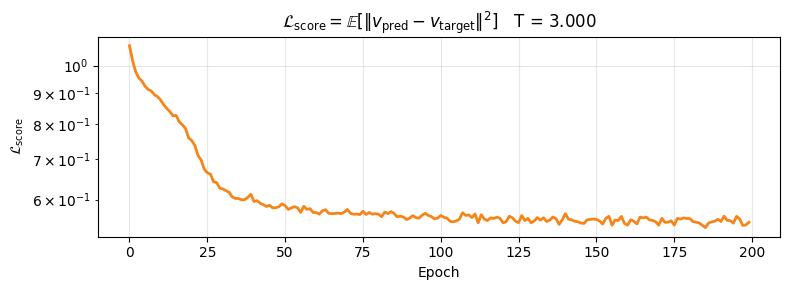


[4/4] Generating 64 configurations at T = 3.0 via DDIM...
  Generated sigma shape : (64, 36)


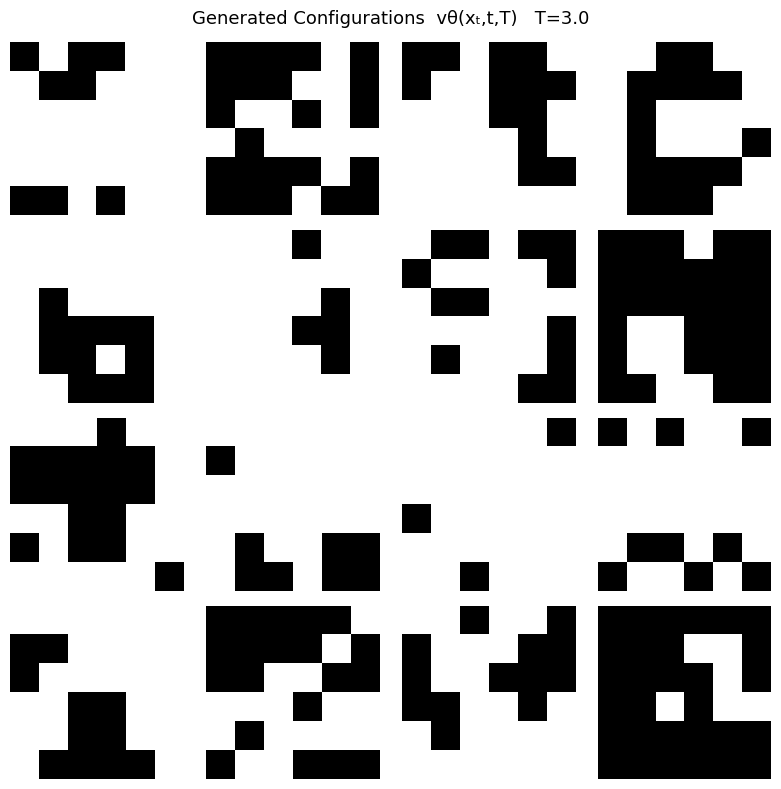

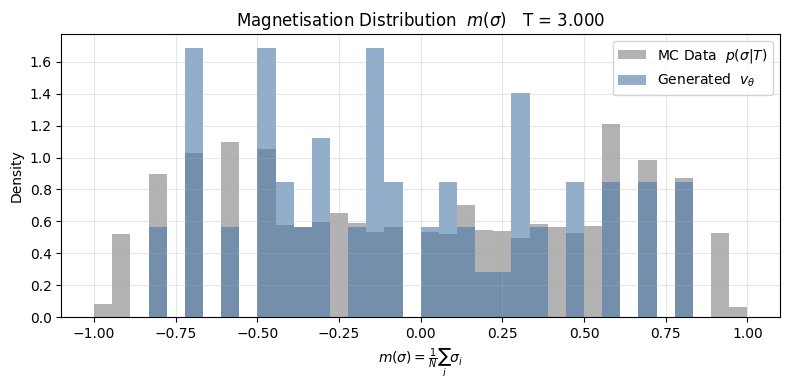

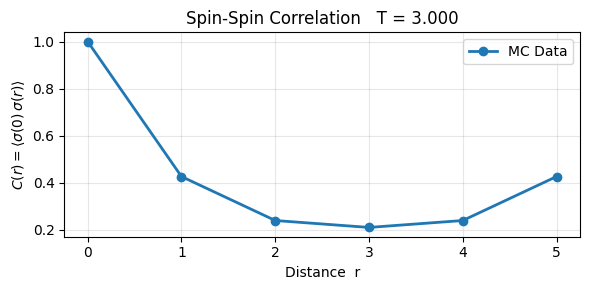

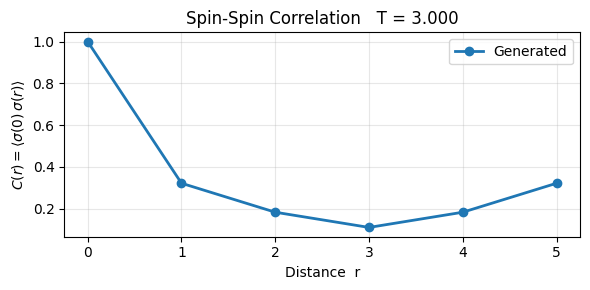

In [18]:
#Build & train vθ(xₜ, t, T)
print("\n Building velocity network vθ(xₜ, t, T)...")
v_theta  = VelocityNetUNet(lattice_L=L, base_ch=base_channels)
n_params = sum(p.numel() for p in v_theta.parameters()
               if p.requires_grad)
print(f"Trainable parameters:{n_params:,}")
print(f"U-Net depth:{v_theta.depth}")

print("\nTraining  L_score = E[||v_pred - v_target||²]")
v_theta, theta_ema, L_score_history = train_score_model(
    v_theta, dataloader, device,
    n_epochs=n_epochs, lr=lr, ema_decay=ema_decay,
    grad_clip=grad_clip, warmup=warmup_epochs,
)
plot_L_score(L_score_history, T=T_train)

# Generate σ via DDIM with θ_EMA
print(f"\Generating {n_samples_gen} configurations "
      f"at T = {T_train} via DDIM...")
sigma_generated = ddim_sample(
    theta_ema,
    T_phys = T_train,
    n_configs= n_samples_gen,
    device = device,
    n_steps= ddim_steps,
    eta = eta,
    disc_method = discretize,
    tanh_k = tanh_k_final,
    lattice_L = L,
    T_min= T_min,
    T_max = T_max,
)
print(f"  Generated sigma shape : {sigma_generated.shape}")

plot_spin_configurations(
    sigma_generated, L,
    title=f"Generated Configurations  vθ(xₜ,t,T)   T={T_train}",
    num_show=16,
)

# Compare m(σ) distributions
m_gen = sigma_generated.mean(axis=1)
plot_magnetization_distribution(m_mc, m_gen, T=T_train)

# Compare C(r) = <σ(0)σ(r)>
plot_spin_spin_correlation(sigma_dataset,   L,
                           label="MC Data",   T=T_train)
plot_spin_spin_correlation(sigma_generated,  L,
                           label="Generated", T=T_train)

## Generate and analyze data for T_train = 1.0

Device  : cuda
Lattice : L=6,  N=L²=36 spins
New T_train : 1.000   (T_c ≈ 2.269)

[1/4] Generating / loading Ising spin configurations for new T_train...
[Data] Generating: L=6, T=1.000, workers=8, steps/worker=625
[Data] Saved 5000 configs → ising_L6_T1.000.npy  shape=(5000, 36)
  new_sigma_dataset : (5000, 36)
  new_T_scaled      : 0.1250
  Batches/epoch : 19


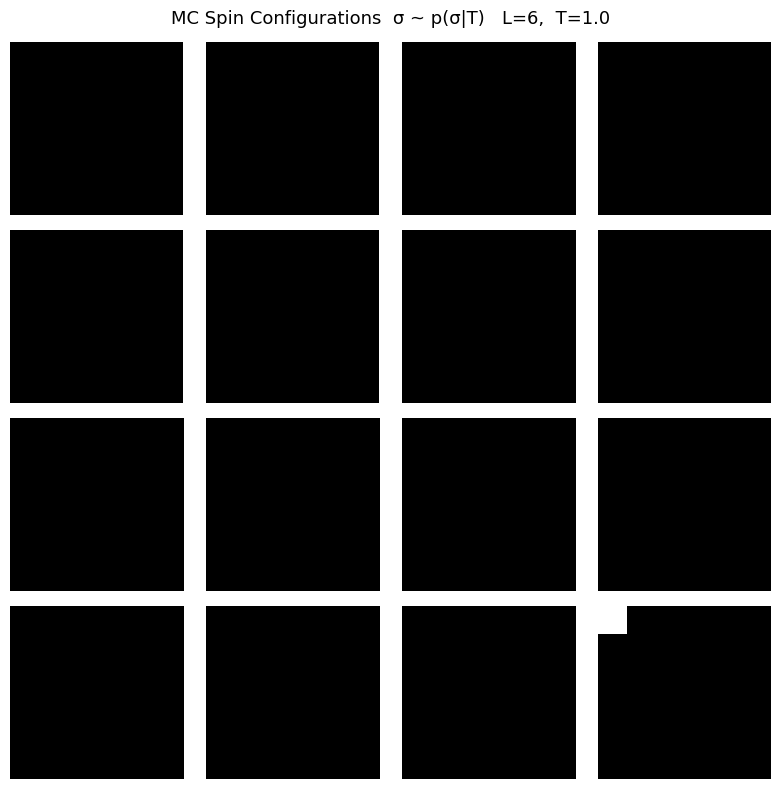

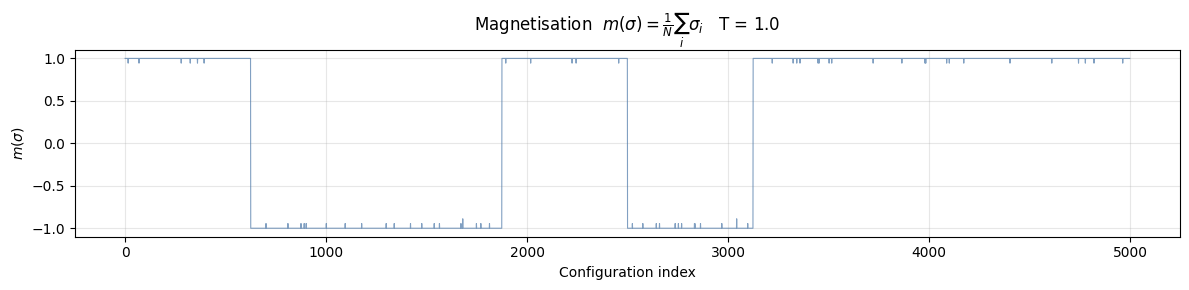

In [19]:
new_T_train = 1.0 # Set the new training temperature

print(f"Device  : {device}")
print(f"Lattice : L={L},  N=L²={N} spins")
print(f"New T_train : {new_T_train:.3f}   (T_c ≈ {T_c:.3f})")


print("\nGenerating / loading Ising spin configurations ")
new_sigma_dataset = generate_ising_configurations(
    lattice_L=L, T=new_T_train,
    mc_sw=mc_sweeps, eq_sw=eq_sweeps, s_intv=sample_intv,
)

new_T_scaled_train = float(
    np.clip((new_T_train - T_min) / (T_max - T_min), 0.0, 1.0)
)
new_T_labels = np.full(
    (len(new_sigma_dataset), 1), new_T_scaled_train, dtype=np.float32
)
print(f"  new_sigma_dataset : {new_sigma_dataset.shape}")
print(f"  new_T_scaled      : {new_T_scaled_train:.4f}")

new_bs = min(batch_size, len(new_sigma_dataset))
if new_bs < 2:
    raise RuntimeError("Too few samples — increase mc_sweeps.")

new_dataloader = DataLoader(
    TensorDataset(torch.tensor(new_sigma_dataset),
                  torch.tensor(new_T_labels)),
    batch_size=new_bs, shuffle=True, drop_last=True, num_workers=0,
)
print(f"  Batches/epoch : {len(new_dataloader)}")

# ── 2. Visualise MC data for new T_train ────────────────────────────────────
plot_spin_configurations(
    new_sigma_dataset, L,
    title=f"MC Spin Configurations  σ ~ p(σ|T)   L={L},  T={new_T_train}",
    num_show=16,
)

# m(σ) = (1/N) Σᵢ σᵢ  time series  (Eq. 5)
new_m_mc = new_sigma_dataset.mean(axis=1)
plt.figure(figsize=(12, 3))
plt.plot(new_m_mc, color="#4C78A8", alpha=0.7, lw=0.8)
plt.title(
    r"Magnetisation  $m(\sigma) = \frac{1}{N}\sum_i \sigma_i$"
    f"   T = {new_T_train}"
)
plt.xlabel("Configuration index")
plt.ylabel(r"$m(\sigma)$")
plt.ylim(-1.1, 1.1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


 Building velocity network vθ(xₜ, t, T) for new T_train...
Trainable parameters:684,033
U-Net depth:1

Training  L_score = E[||v_pred - v_target||²] for new T_train
  [Epoch 001/200]  L_score=1.188083  lr=1.00e-05
  [Epoch 020/200]  L_score=0.156068  lr=1.00e-04
  [Epoch 040/200]  L_score=0.151721  lr=9.70e-05
  [Epoch 060/200]  L_score=0.137161  lr=8.83e-05
  [Epoch 080/200]  L_score=0.120475  lr=7.50e-05
  [Epoch 100/200]  L_score=0.117259  lr=5.87e-05
  [Epoch 120/200]  L_score=0.120013  lr=4.13e-05
  [Epoch 140/200]  L_score=0.124332  lr=2.50e-05
  [Epoch 160/200]  L_score=0.108290  lr=1.17e-05
  [Epoch 180/200]  L_score=0.117861  lr=3.02e-06
  [Epoch 200/200]  L_score=0.110696  lr=0.00e+00


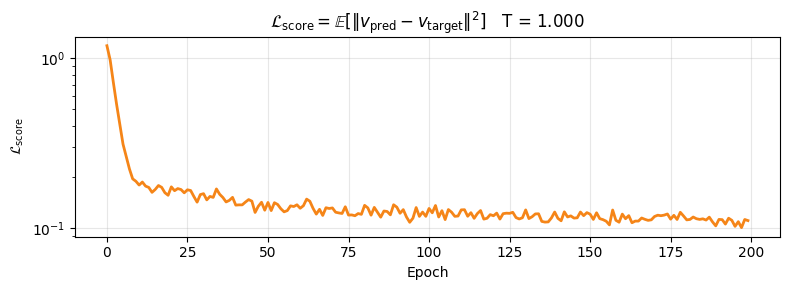


Generating 64 configurations at T = 1.0 via DDIM...
  Generated sigma shape : (64, 36)


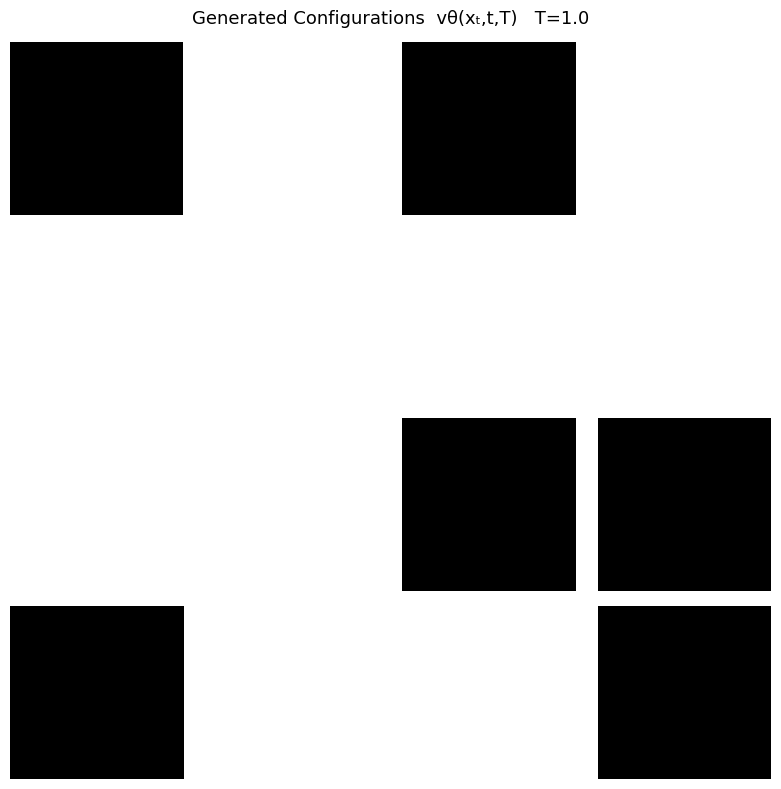

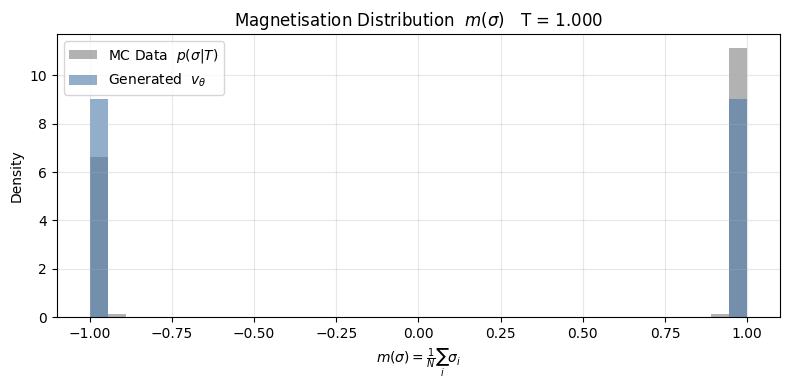

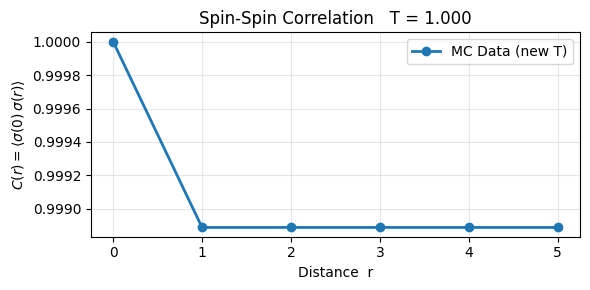

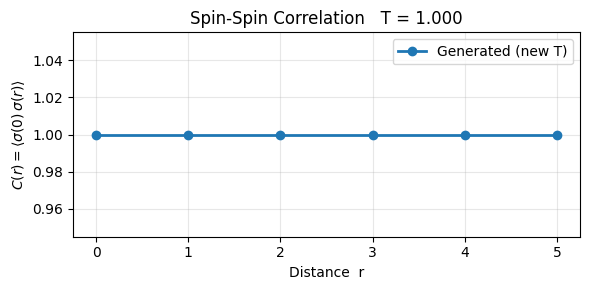

In [20]:

print("\n Building velocity network vθ(xₜ, t, T) ")
new_v_theta  = VelocityNetUNet(lattice_L=L, base_ch=base_channels)
new_n_params = sum(p.numel() for p in new_v_theta.parameters()
               if p.requires_grad)
print(f"Trainable parameters:{new_n_params:,}")
print(f"U-Net depth:{new_v_theta.depth}")

print("\nTraining  L_score = E[||v_pred - v_target||²] ")
new_v_theta, new_theta_ema, new_L_score_history = train_score_model(
    new_v_theta, new_dataloader, device,
    n_epochs=n_epochs, lr=lr, ema_decay=ema_decay,
    grad_clip=grad_clip, warmup=warmup_epochs,
)
plot_L_score(new_L_score_history, T=new_T_train)


print(f"\nGenerating {n_samples_gen} configurations "
      f"at T = {new_T_train} via DDIM...")
new_sigma_generated = ddim_sample(
    new_theta_ema,
    T_phys = new_T_train,
    n_configs= n_samples_gen,
    device = device,
    n_steps= ddim_steps,
    eta = eta,
    disc_method = discretize,
    tanh_k = tanh_k_final,
    lattice_L = L,
    T_min= T_min,
    T_max = T_max,
)
print(f"  Generated sigma shape : {new_sigma_generated.shape}")

plot_spin_configurations(
    new_sigma_generated, L,
    title=f"Generated Configurations  vθ(xₜ,t,T)   T={new_T_train}",
    num_show=16,
)

# Compare m(σ) distributions
new_m_gen = new_sigma_generated.mean(axis=1)
plot_magnetization_distribution(new_m_mc, new_m_gen, T=new_T_train)

# Compare C(r) = <σ(0)σ(r)>
plot_spin_spin_correlation(new_sigma_dataset,   L,
                           label="MC Data ",   T=new_T_train)
plot_spin_spin_correlation(new_sigma_generated,  L,
                           label="Generated ", T=new_T_train)